In [1]:
import os
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from autoencoder.model_qwen import QwenAutoencoder
from qwen_vl import *
from PIL import Image

In [3]:
base_dir = Path('output/cholecseg8k/video01_00080_qwen_cat')
data_dir = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/qwen_instance_features_dim3')
data_dir_f = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/qwen_patch_features_dim3')
img_dir = base_dir / 'video_rgb/ours_10000/gt'
gt_feat_dir = base_dir / 'video_lang/ours_10000/gt_npy'
render_feat_dir = base_dir / 'video_lang/ours_10000/renders_npy'

In [4]:
frame = 50

img = Image.open(img_dir / f'{frame:05}.png')
gt_feat = np.load(gt_feat_dir / f'{frame:05}.npy')[..., :3]
gt_patch_f = np.load(data_dir_f / f'{frame+1:06}_f.npy')
render_feat = np.load(render_feat_dir / f'{frame:05}.npy')[..., :3]
seg = np.load(data_dir / f'{frame+1:06}_s.npy')[0]
gt_patch_feat = gt_patch_f.reshape(17, 20, 3)

In [5]:
col_transform = lambda c: c/2+0.5

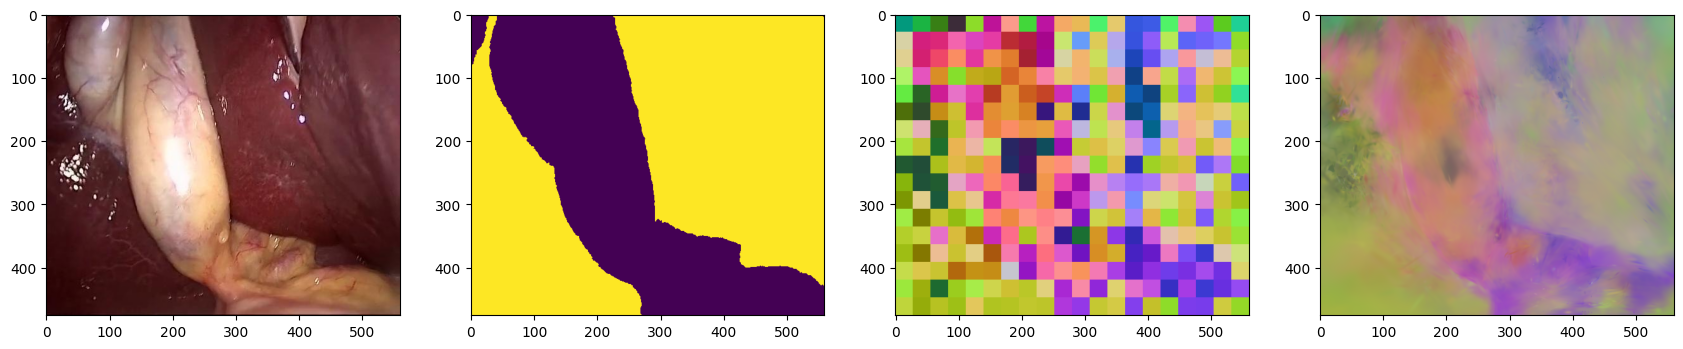

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(21, 9))
axs[0].imshow(img)
axs[1].imshow(seg == 2)
axs[2].imshow(col_transform(gt_feat))
axs[3].imshow(col_transform(render_feat))
plt.show()

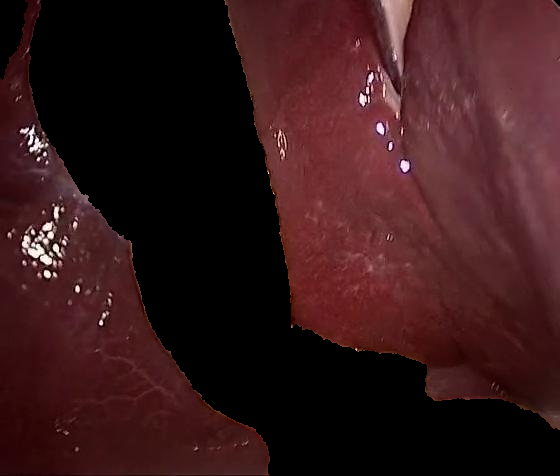

In [7]:
liver_only_np = np.array(img) * (seg == 2)[..., np.newaxis]
# liver_only_np[:, :img.width//3] = 0
liver_only = Image.fromarray(liver_only_np)
liver_only

In [8]:
model, processor = get_patched_qwen(use_bnb_4bit=False)
ae_ckpt_path = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/autoencoder/best_ckpt.pth')
ae = QwenAutoencoder(latent_dim=3).to("cuda:1")
ae.load_state_dict(torch.load(ae_ckpt_path))
ae.eval()
pass

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 1 has a total capacity of 47.41 GiB of which 12.00 MiB is free. Process 52659 has 44.54 GiB memory in use. Including non-PyTorch memory, this process has 2.82 GiB memory in use. Of the allocated memory 2.54 GiB is allocated by PyTorch, and 29.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

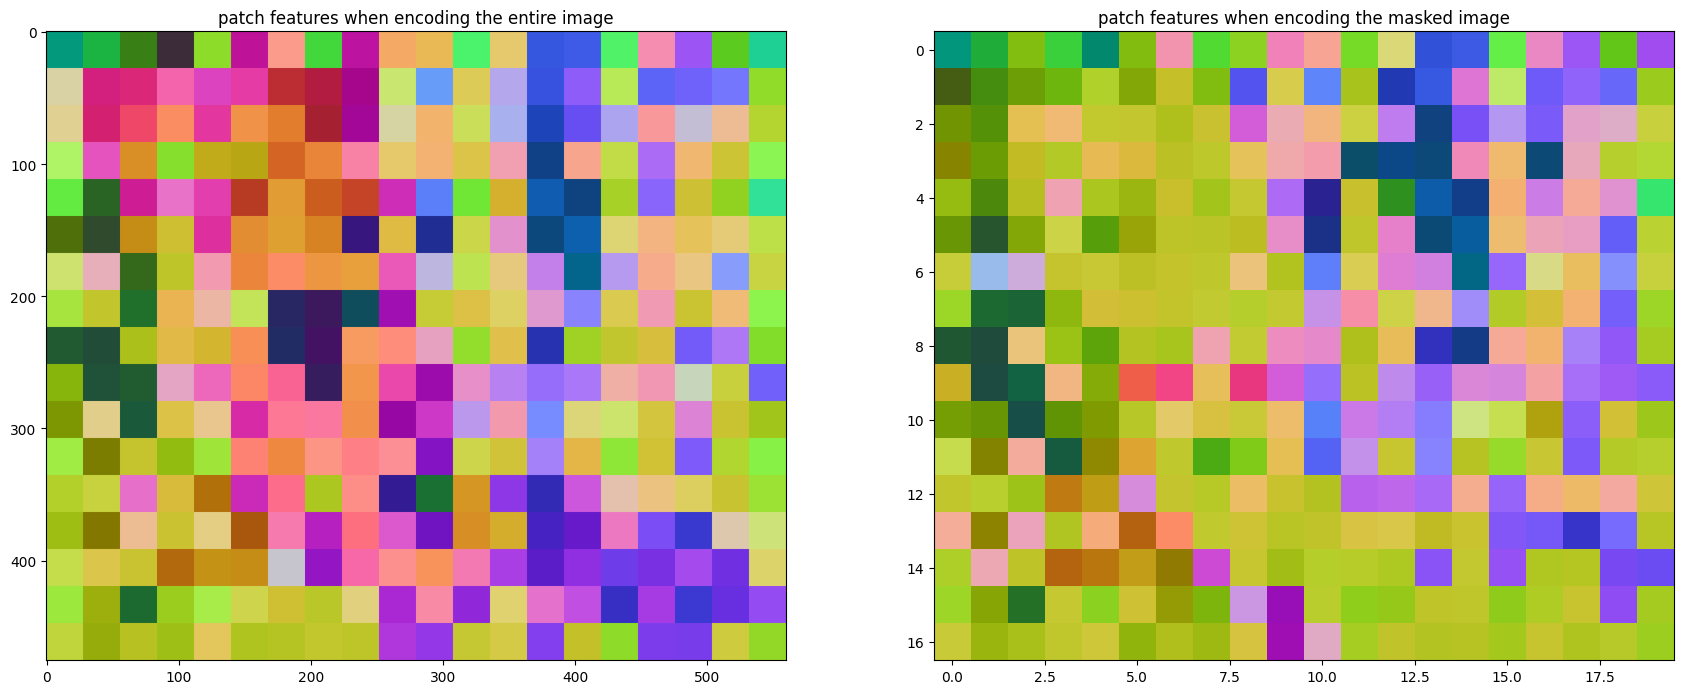

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(21, 9))
axs[0].imshow(col_transform(gt_feat))
axs[0].set_title('patch features when encoding the entire image')
liver_only_feats = ae.encode(qwen_encode_image(liver_only, model, processor).float()).reshape(17, 20, -1).detach().cpu().float().numpy()
axs[1].imshow(col_transform(liver_only_feats))
axs[1].set_title('patch features when encoding the masked image')
plt.show()

In [20]:
ask_qwen_about_image_features(ae.decode(torch.tensor(liver_only_feats.reshape(-1, 3), device='cuda:1')), "Which organ is this?", model, processor)

'This appears to be the gallbladder, which is located in the upper right quadrant of the abdomen, adjacent to the liver.'

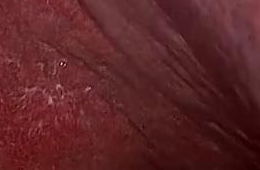

In [57]:
liver_crop = img.crop((300, 110, img.width, 280))
liver_crop

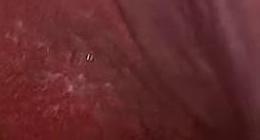

In [51]:
liver_crop = img.crop((300, 180, img.width, 320))
liver_crop

In [24]:
selected_seg_id = 2

In [22]:
patch_coords = np.meshgrid(np.arange(0, img.height // 28), np.arange(0, img.width // 28), indexing='ij')
patch_centers = np.meshgrid(np.arange(0, img.height, 28)+14, np.arange(0, img.width, 28)+14, indexing='ij')
patch_seg = seg[patch_centers[0], patch_centers[1]]
# seg_patches = np.stack(patch_coords, axis=-1).reshape(-1, 2)[seg.ravel() == selected_seg_id]

In [25]:
seg_upper_crop = (patch_seg == selected_seg_id).any(axis=1).argmax()
seg_lower_crop = (patch_seg == selected_seg_id).any(axis=1)[::-1].argmax()
seg_left_crop = (patch_seg == selected_seg_id).any(axis=0).argmax()
seg_right_crop = (patch_seg == selected_seg_id).any(axis=0)[::-1].argmax()

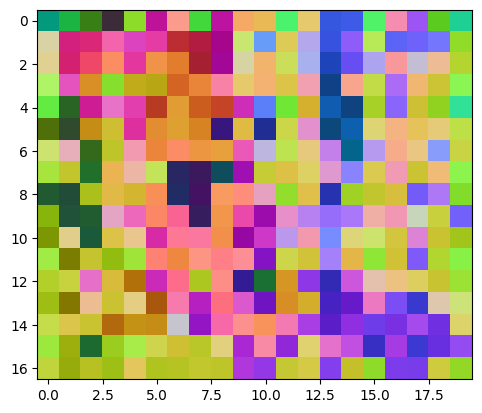

In [26]:
seg_crop_feats = gt_patch_feat[seg_upper_crop:17-seg_lower_crop+1, seg_left_crop:20-seg_right_crop+1]
plt.imshow(col_transform(seg_crop_feats))
plt.show()

In [27]:
seg_feats = gt_patch_feat.reshape(-1, 3)[patch_seg.ravel() == selected_seg_id]

In [143]:
seg_feats.shape

(212, 3)

In [28]:
selected_seg_centers = np.stack(patch_centers, axis=-1).reshape(-1, 2)[patch_seg.ravel() == selected_seg_id]

In [29]:
render_seg_feats = render_feat[selected_seg_centers[:,0], selected_seg_centers[:,1]]

In [30]:
render_seg_feats.shape

(212, 3)

In [75]:
ask_qwen_about_image(img, "Which organs are present?", model, processor)

'The image shows the gallbladder and part of the liver. The gallbladder is the yellowish organ on the left side of the image, and it appears to be in the process of being removed or dissected. The liver is visible on the right side of the image.'

In [31]:
# crop features
ask_qwen_about_image_features(
    ae.decode(torch.tensor(seg_crop_feats.reshape(-1, 3), device='cuda:1')),
    "Which organ is this?", model, processor
)

'This image shows the gallbladder. It appears to be in situ, likely during a surgical procedure such as a cholecystectomy.'

In [32]:
# mask features
ask_qwen_about_image_features(
    ae.decode(torch.tensor(seg_feats, device='cuda:1')),
    "Which organ is this?", model, processor
)

"This image shows the liver. The visible structure is part of the liver's surface, which appears to be in the abdominal cavity during a surgical procedure."

In [148]:
# rendered mask features
ask_qwen_about_image_features(
    ae.decode(torch.tensor(render_seg_feats, device='cuda:1')),
    "Which organ is this?", model, processor
)

"This image shows the liver. The texture and coloration are characteristic of the liver's surface, which is typically a deep red-brown color. The visible veins and the overall structure are consistent with the liver's anatomy."